# Chapter 41. Naive Bayes Classification

Bayesian classification methods rely on Bayes' Theorem.
Bayes' Theorem describe the relationship of conditional probabilities in light of prior information.

If we are interested in finding the probability that an event $L$ occurs given that we have observe certain _features_ in the data, we can express it as $P(L|features)$. Bayes' Theorem tells us this can be calculated as:

$$P(L|features) = \frac{P(features|L)P(L)}{P(features)}$$



If our goal is to decide between two labels (binary classification) $L_1$ and $L_2$, then we can compute it by the ratio of posterior probabilities:

$$\frac{P(L_1|features)}{P(L_2|features)}=\frac{P(features|L_1)P(L_1)}{P(features|L_2)P(L_2)}$$


All we need is a model by which we can compute $P(features|L_i)$ for each label.
Such model is called _generative model_. It hypothesies the random process that generates the data. Specifying this model is the main piece of training a Bayesian classifier.

This is where the name "naive" comes from: making naive assumptions about the generative process of the data to find an approximation to it.


In [33]:
%matplotlib inline
# basic imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Gaussian Naive Bayes

Gaussian naive Bayes assumes the data is drawn from a _Gaussian distribution_ (aka Normal distribution).

Let us generate some data:

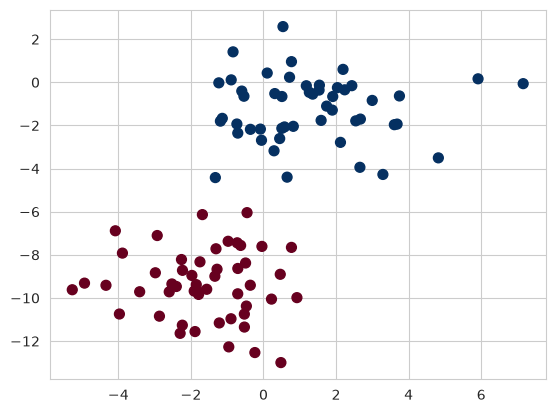

In [34]:
from sklearn.datasets import make_blobs

X, y = make_blobs(100, 2, centers=2, random_state=2, cluster_std=1.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='RdBu');

Fitting a GaussianNB model in sklearn to find the generative of each class:

In [35]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X,y);

Generating new data to predict labels:

In [36]:
rng = np.random.RandomState(0)
Xnew = [-6, -14] + [14, 18] * rng.rand(2000, 2)
ynew = model.predict(Xnew)

Let's plot this new data to visualize the __decision boundary__ learned from the data:

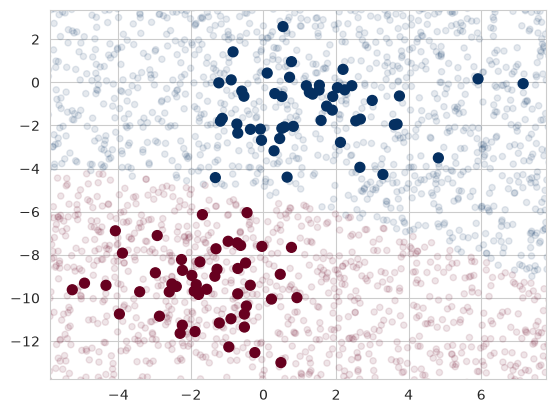

In [37]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='RdBu')
lim = plt.axis()
plt.scatter(Xnew[:, 0], Xnew[:, 1], c=ynew, s=20, cmap='RdBu', alpha=0.1)
plt.axis(lim);

The Bayesian formalism allows for probabilistic classification, which we can obtain using `predict_proba`:

In [38]:
yprob = model.predict_proba(Xnew)
yprob[-8:].round(2)

array([[0.89, 0.11],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.  , 1.  ],
       [0.15, 0.85]])

The above result is the probability that each point belongs in classes 1 and 2, respectively. For instance, the first data point was predicted to have a probability of 0.89 (89%) of being in class 1 versus 0.11 (11%) of being in class 2.

Notice that `GaussianNB` is non-parametric. We do not learn any parameters from training, we simply make an assumption about the data distribution and fit the data according to this assumption.

# Chapter 44: Decision Trees and Random Forests

Random Forests is another nonparametric algorithm built of multiple _Decision Trees_.
Random Forests is called an __ensemble method__ because it relies on multiple, smaller models _voting_ on an output. Votes are aggregated by a majority count, which is taken as the output of a Random Forest model.

__The sum can be greater than the parts__: Often, the majority voting of multiple decision trees in a random forests model can outperform the vote of a single decision tree.

# Decision Trees

Decision trees are intuitive ways to classify an object: ask a series of questions about it to close in on the classification.

For example, a decision tree to classify animals:

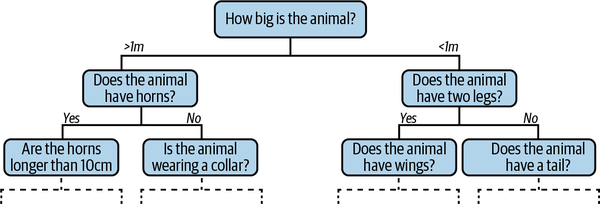

## Creating a Decision Tree

Generating synthetic data:

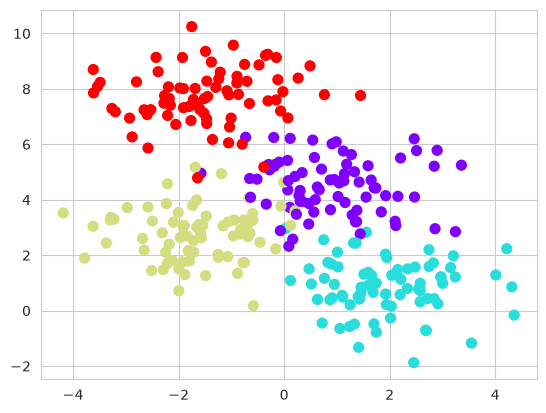

In [39]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=1.0)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='rainbow');

A decision tree will iteratively split the data along one or the other axis according to some criterion:

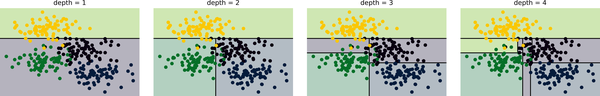

A region that contains only points of a single class is not split again.

Fitting a `DecisionTreeClassifier`:

In [40]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier().fit(X, y)

The following utility help us visualize a decision tree classifier:

In [41]:
def visualize_classifier(model, X, y, ax=None, cmap='rainbow'):
    ax = ax or plt.gca()

    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=cmap,
                clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # fit the estimator
    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                            np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Create a color plot with the results
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                            levels=np.arange(n_classes + 1) - 0.5,
                            cmap=cmap, zorder=1)

    ax.set(xlim=xlim, ylim=ylim)

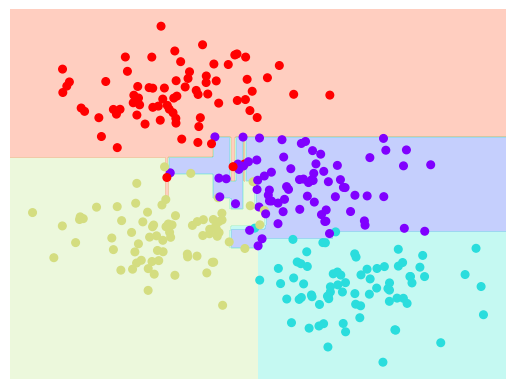

In [42]:
visualize_classifier(DecisionTreeClassifier(), X, y)

Notice how decision trees may generate strangely shaped decision boundaries. This occurrs because of _overfitting_ and can be controlled by the `max_depth` hyperparameter of `DecisionTreeClassifier`.

## Decision Trees and Overfitting

It is very easy for the decision tree to go deep and overfit to the data.

Let us look at two trees trained on different subsets of the data:

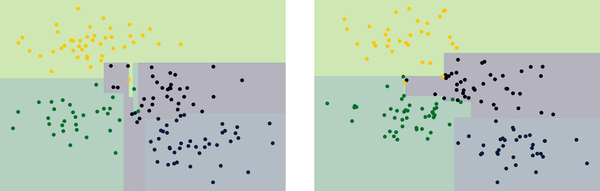

One observation is that combining information from both trees might lead to better results.

# Ensemble of Estimators: Random Forests

The notion that multiple overfitting estimators can be combined to reduce the effect of overfitting is the underlying principle of _Random Forests_: An ensemble of decision trees.

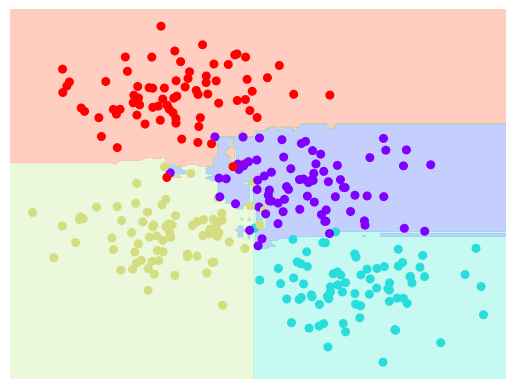

In [43]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=0)
visualize_classifier(model, X, y);

# Example: Random Forests for Classifying Digits

Let's use Random Forecsts on the handwritten digits dataset:

In [44]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

Let us visualize the digits:

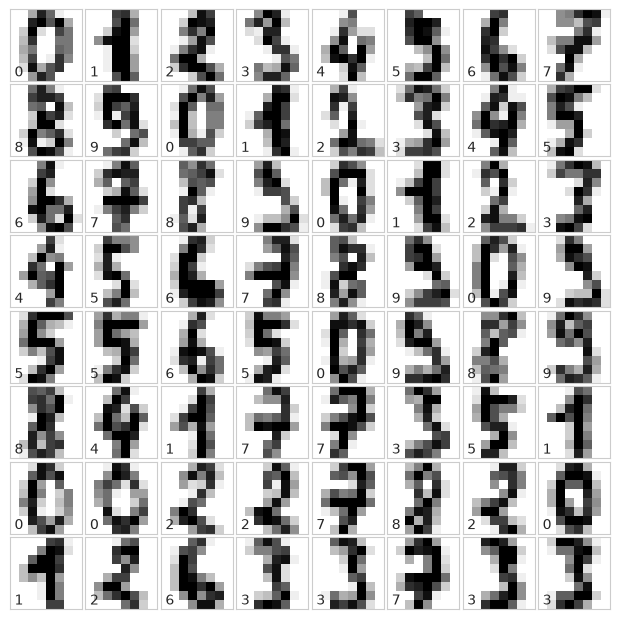

In [45]:
# set up the figure
fig = plt.figure(figsize=(6, 6))  # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1,
                    hspace=0.05, wspace=0.05)

# plot the digits: each image is 8x8 pixels
for i in range(64):
    ax = fig.add_subplot(8, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation='nearest')

    # label the image with the target value
    ax.text(0, 7, str(digits.target[i]))

Setting up a Random Forests classifier:

In [ ]:
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(digits.data, digits.target,
                                                random_state=0)
model = RandomForestClassifier(n_estimators=1000)
model.fit(Xtrain, ytrain)
ypred = model.predict(Xtest)

In [ ]:
from sklearn import metrics
print(metrics.classification_report(ypred, ytest))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        38
           1       0.98      0.95      0.97        44
           2       0.95      1.00      0.98        42
           3       0.98      0.98      0.98        45
           4       0.97      1.00      0.99        37
           5       0.98      0.96      0.97        49
           6       1.00      1.00      1.00        52
           7       1.00      0.96      0.98        50
           8       0.94      0.98      0.96        46
           9       0.98      0.98      0.98        47

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



How well did the model do? We will use Scikit-Learn's `classification_report`, which outputs the _precision_, _recall_, _f1-score_, _support_ for each class (digit, in this case).
It also reports the overall _accuracy_, _macro average_ (unweighted) and _weighted average_. 

|Metric|Description|Definition|
|---|---|---|
|Precision|The ratio of positive predictions to all predictions|$Precision = \frac{TP}{TP+FP}$|
|Recall|The ratio of positive predictions to all positive samples|$Recall = \frac{TP}{TP+FN}$|
|F1-score|The harmonic mean of _precision_ and _recall_|$F_1=  2\frac{Precision\times Recall}{Precision+Recall}$|
|Accuracy|The ratio of samples predicted correctly|$Accuracy=\frac{\sum_{i}^n\hat{y}_i=y_{i}}{n}$|
|Support|The number of data in each class||

Where $n$ is the number of samples, $\hat{y_i}$ is the predicted class, $y_i$ is the true class, $TP$ is the number of true-positive outcomes, $FP$ are false-positive outcomes and $FN$ are false-negative outcomes.


### Why Precision, Recall and $F_1$?

Suppose you are developing a model to predict if a patient has a very rare disease that only occurrs with a frequency of 1 to 100,000. A uniform sample of the population will, thus, have 1 patient with the disease for every 100,000 individuals.

If you train a model on such dataset, it may achieve very high accuracy by simply predicting that no one has the disease, resulting in an accuracy of $0.999$. However, if we measure precision and recall, we would get $Precision=\frac{0}{99,999}$ and $Recall=\frac{0}{1}$, resulting in $F_1=0$. 

$F_1$ is a stronger indicator of the model's performance because it accounts for class imbalance by combining precision and recall.

### Exercise

What would be the precision and recall in the above if the model did the opposite and predicted every patient had the disease?

## Confusion matrix

A confusion matrix shows how well a model classifies data from each labels, and the errors it makes:

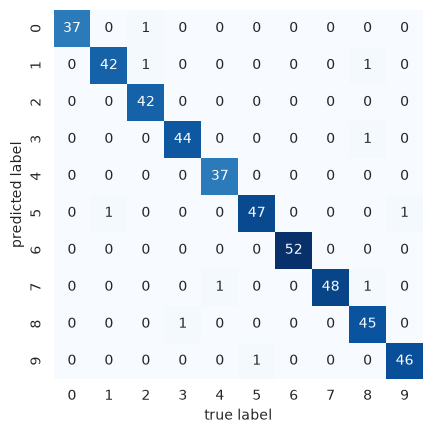

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
mat = confusion_matrix(ytest, ypred)
sns.heatmap(mat.T, square=True, annot=True, fmt='d',
            cbar=False, cmap='Blues')
plt.xlabel('true label')
plt.ylabel('predicted label');

# Chapter 43: Support Vector Machines

A Support Vector Machine (SVM) is a type of distriminative classifier. It predicts classes by learning a function that describes a decision boundary between classes.

Consider the following data of well-separated poins:

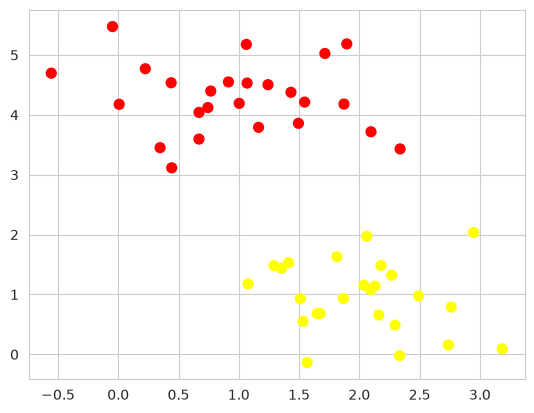

In [ ]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2,
                    random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');

A linear discriminative classifier may attempt to draw a straight line separating the two sets of data:

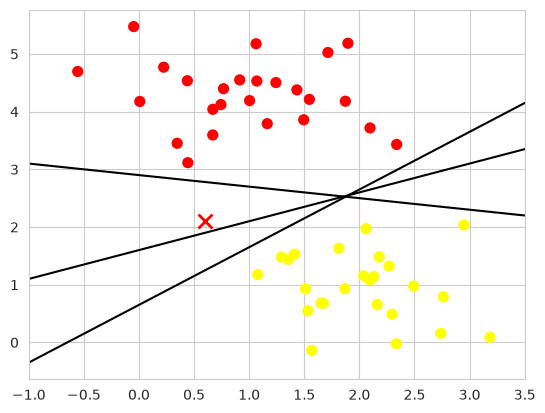

In [ ]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.plot([0.6], [2.1], 'x', color='red', markeredgewidth=2, markersize=10)

for m, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    plt.plot(xfit, m * xfit + b, '-k')

plt.xlim(-1, 3.5);

These are different separators that perfectly discriminate the training data.
However, when a new datapoint is added ("X"), each will assign different labels to it.
Which line is the best?

# SVM: Maximizing the Margin

The intuition behind SVMs is to include a _margin_ around the discriminator that separates data from each class. It would like like this:

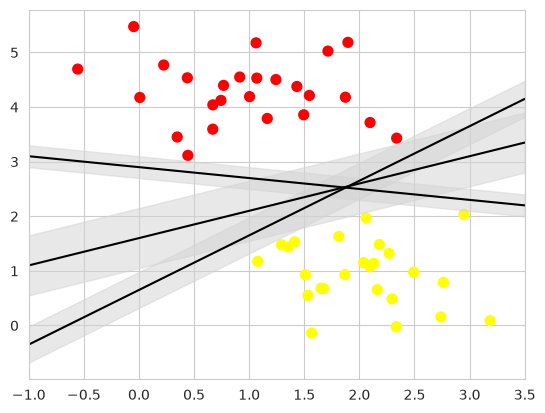

In [ ]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                        color='lightgray', alpha=0.5)

plt.xlim(-1, 3.5);

## Fitting an SVM

Scikit-Learn's support vector classifier (`SVC`) implements an SVM classifier model:

In [ ]:
from sklearn.svm import SVC # "Support vector classifier"
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10000000000.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


The SVC model from above uses a linear kernel and a very large margin threshold `C`.

Let us add a helper function to visualize the SVM decision boundary:

In [ ]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
                levels=[-1, 0, 1], alpha=0.5,
                linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                    model.support_vectors_[:, 1],
                    s=300, linewidth=1, edgecolors='black',
                    facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

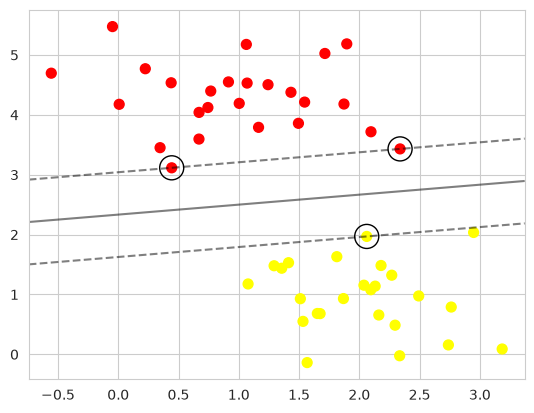

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model);

Notice that the SVM chose the discriminator that maximizes the margin between the two sets of points.
The points touching the margin are named _support vectors_.

A key aspect of SVMs is that only support vectors matter. Any point further from the margin that are on the correct side to not modify the fit.

## Non-linear SVM kernels

If the relation between the data at hand is not linear, we may have to use a different kernel for the SVC:

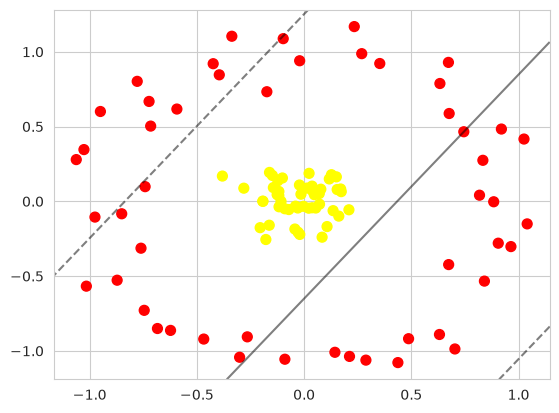

In [ ]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

A _kernel transformation_ applies a transform function to the data in order to make it "separable" in at higher dimensions.
One such kernels is the _radial basis funcion_(rbf) kernel.
We can specify the kernel to be used with the `kernel` parameter:

In [ ]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1000000.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


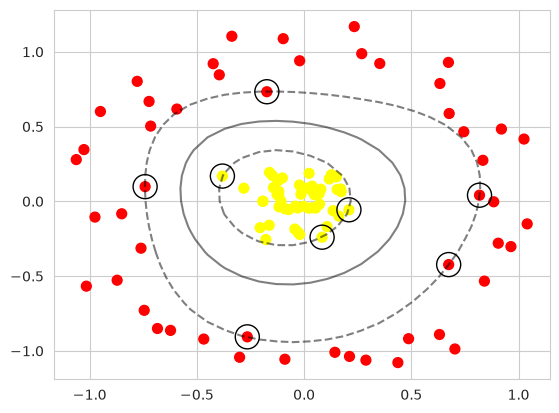

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none');

## Softening the Margins

As you may have noticed, we have applied an SVM to a perfectly separable set of points. And our enforcement of the margin was very strict: every point should be on or behind the margin.

In reality, such separation may not possible. For instance, the data may look like:

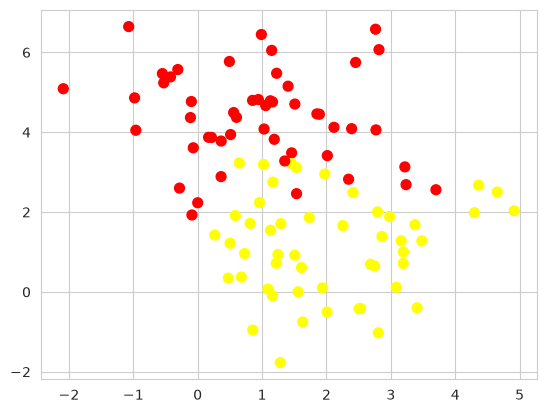

In [ ]:
X, y = make_blobs(n_samples=100, centers=2,
                random_state=0, cluster_std=1.2)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');

To handle this case, the SVM implementation includes a parameter that "softens" the margin, allowing some points to creep into it if that allows for a better fit.

The hardness of the margin is controlled by parameter `C`. For very large `C`, the margin is hard and allows no point within it. For smaller `C`, the margin allows a few points inside.

Let us compare two differnt values of `C`:

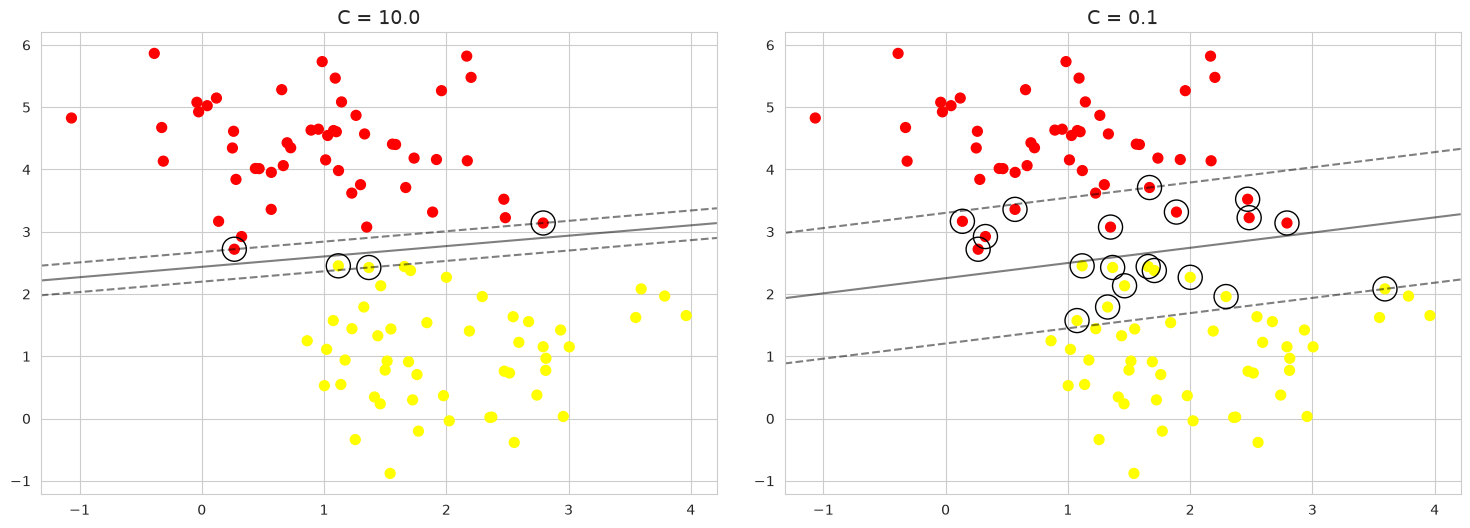

In [ ]:
X, y = make_blobs(n_samples=100, centers=2,
                           random_state=0, cluster_std=0.8)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [10.0, 0.1]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)

# On to the lab

Face regnition using SVMs:

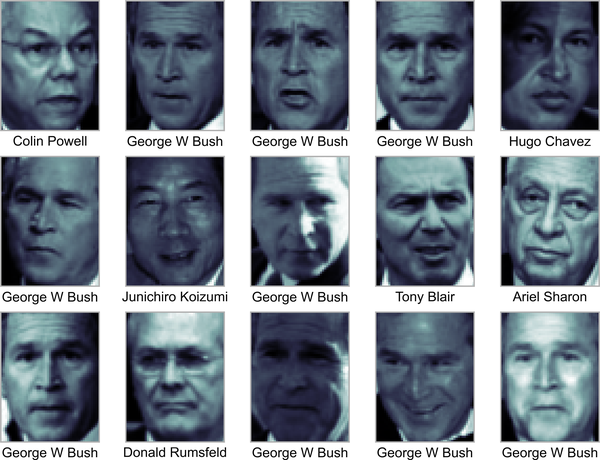
